In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sbga211
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:01<00:00, 755kB/s]

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
data_df = pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [4]:
data_df.dropna(inplace = True)
data_df.drop(['id'], axis = 1, inplace = True)
print(data_df.shape)

(18185, 11)


In [5]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [6]:
print(data_df["Class"].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [7]:
original_df = data_df.copy()

for column in data_df.columns:
  data_df[column] = data_df[column]/data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [8]:
X = np.array(data_df.iloc[:, :-1])
Y = np.array(data_df.iloc[:, -1])

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3)

In [10]:
X_test, X_val, Y_test, Y_val = train_test_split(X_test, Y_test, test_size = 0.5)

In [11]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [30]:
class dataset(Dataset):
  def __init__(self, X, Y):
    self.X = torch.tensor(X, dtype = torch.float32).to(device)
    self.Y = torch.tensor(Y, dtype = torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.Y[index]

In [31]:
training_data = dataset(X_train, Y_train)
validation_data = dataset(X_val, Y_val)
testing_data = dataset(X_test, Y_test)

In [32]:
train_dataloader = DataLoader(training_data, batch_size = 8, shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size = 8, shuffle = True)
testing_dataloader = DataLoader(testing_data, batch_size = 8, shuffle = True)


In [33]:
class MyModel1(nn.Module):
    def __init__(self):

        super(MyModel1, self).__init__()

        self.input_layer = nn.Linear(X.shape[1], 10)
        self.linear = nn.Linear(10, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

model10 = MyModel1().to(device)

class MyModel2(nn.Module):
    def __init__(self):

        super(MyModel2, self).__init__()

        self.input_layer = nn.Linear(X.shape[1], 20)
        self.linear = nn.Linear(20, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

model20 = MyModel2().to(device)

class MyModel3(nn.Module):
    def __init__(self):

        super(MyModel3, self).__init__()

        self.input_layer = nn.Linear(X.shape[1], 10)
        self.linear1 = nn.Linear(10, 10)
        self.linear2 = nn.Linear(10, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear1(x)
        x = self.linear2(x)
        x = self.sigmoid(x)
        return x

model1010 = MyModel3().to(device)


In [34]:
summary(model10, (X.shape[1],))
summary(model20, (X.shape[1],))
summary(model1010, (X.shape[1],))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 20]             220
            Linear-2                    [-1, 1]              21
           Sigmoid-3                    [-1, 1]               0
Total params: 241
Trainable params: 241
Non-train

In [28]:
def model_run(model):
    total_loss_train_plot = []
    total_loss_validation_plot = []
    total_acc_train_plot = []
    total_acc_validation_plot = []

    LR = 1e-3
    criterion = nn.BCELoss()
    optimizer = Adam(model.parameters(), lr= LR)
    epochs = 10

    for epoch in range(epochs):
        total_acc_train = 0
        total_loss_train = 0
        total_acc_val = 0
        total_loss_val = 0

        # Training
        for data in train_dataloader:
            inputs, labels = data
            prediction = model(inputs).squeeze(1)
            batch_loss = criterion(prediction, labels)
            total_loss_train += batch_loss.item()
            acc = ((prediction).round() == labels).sum().item()
            total_acc_train += acc
            batch_loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # Validation
        with torch.no_grad():
            for data in validation_dataloader:
                inputs, labels = data
                prediction = model(inputs).squeeze(1)
                batch_loss = criterion(prediction, labels)
                total_loss_val += batch_loss.item()
                acc = ((prediction).round() == labels).sum().item()
                total_acc_val += acc

        total_loss_train_plot.append(round(total_loss_train/1000, 4))
        total_loss_validation_plot.append(round(total_loss_val/1000, 4))
        total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
        total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))

    # Testing
    with torch.no_grad():
      total_loss_test = 0
      total_acc_test = 0
      for data in testing_dataloader:
        inputs, labels = data
        prediction = model(inputs).squeeze(1)
        batch_loss_test = criterion((prediction), labels)
        total_loss_test += batch_loss_test.item()
        acc = ((prediction).round() == labels).sum().item()
        total_acc_test += acc

    print(f"Testing Accuracy Score is: {round((total_acc_test/X_test.shape[0])*100, 2)}%")

    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

    axs[0].plot(total_loss_train_plot, label='Training Loss')
    axs[0].plot(total_loss_validation_plot, label='Validation Loss')
    axs[0].set_title(' Training and Validation Loss over Epochs')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].set_ylim([0, max(max(total_loss_train_plot), max(total_loss_validation_plot)) * 1.1])
    axs[0].legend()

    axs[1].plot(total_acc_train_plot, label='Training Accuracy')
    axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
    axs[1].set_title('Training and Validation Accuracy over Epochs')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy')
    axs[1].set_ylim([min(min(total_acc_train_plot), min(total_acc_validation_plot)) * 0.9, 100])
    axs[1].legend()

    plt.tight_layout()
    plt.show()

Testing Accuracy Score is: 98.42%


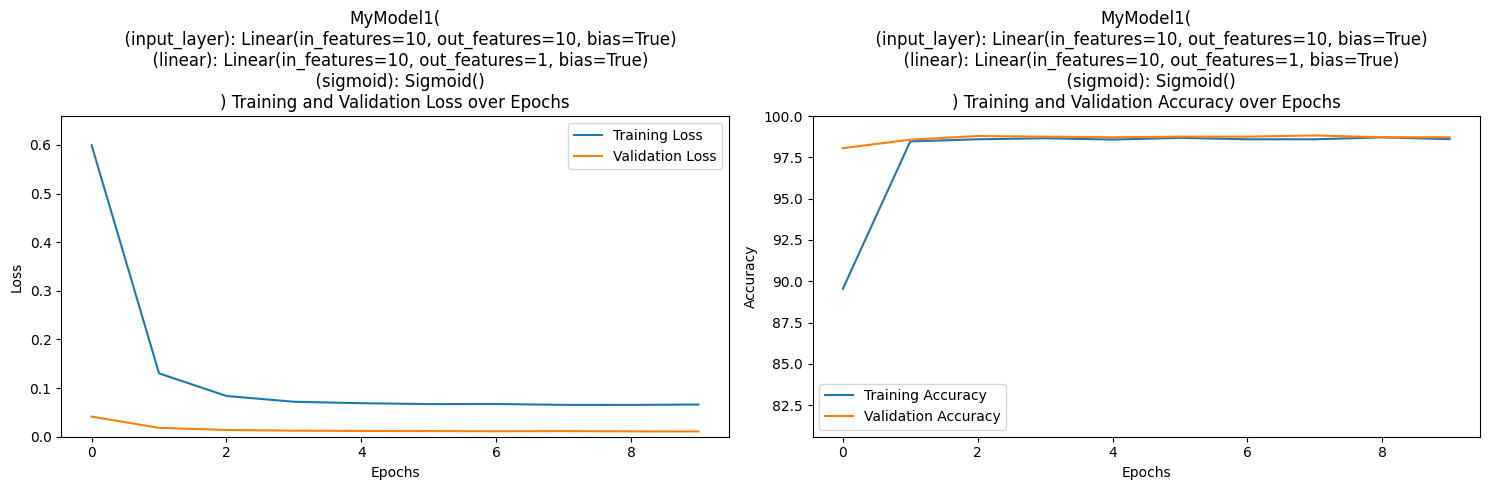

Testing Accuracy Score is: 98.39%


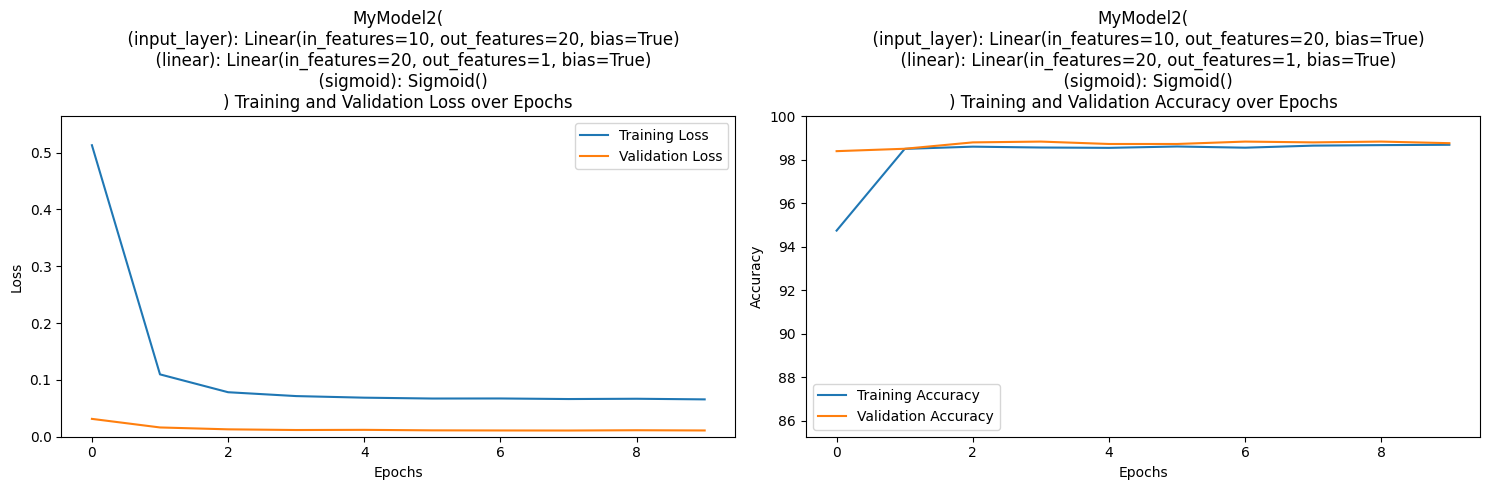

Testing Accuracy Score is: 98.39%


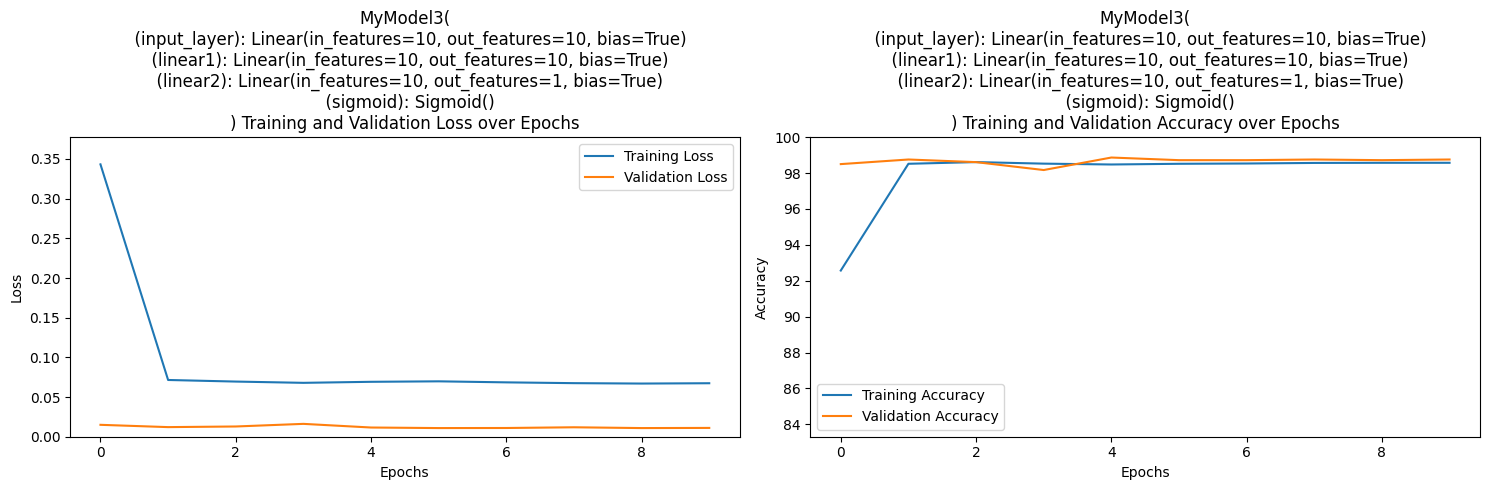

In [35]:
model_run(model10)
model_run(model20)
model_run(model1010)